# Ensemble Strategy as Linear Regression: Combine MR and MOM using OLS

It's commonly known that MR (Mean Reversion) performs well in ranging markets, while MOM (Momentum) tends to excel in trending markets. In `ensemble_strategy.ipynb`, we combined these two strategies based on an ADX-based sigmoid weighting function.

In this notebook, we express the ensemble combination as a **linear regression model** where the target is the future return of the traded stock, and the independent variables are the normalized Mean Reversion and Momentum signals:

$$S_{combined, t+1} = \beta_0 + \beta_1 \cdot S_{MR, t} + \beta_2 \cdot S_{MOM, t} + \epsilon$$

This allows the data to dynamically and optimally determine the weights for each strategy based on historical relationships on the training set.

In [59]:
import talib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import yfinance as yf

In [60]:
STOCK = "AVGO"
MR_PAIR = "EBAY"
WINDOW = {
  "start": "2022-10-01",
  "end": "2026-09-01"
}
TRAIN_WINDOW = {
  "start": "2022-10-01",
  "end": "2025-09-30"
}
TEST_WINDOW = {
  "start": "2025-10-01",
  "end": "2026-09-01"
}
TRAIN_RANGE = slice("2022-10-01", "2025-09-30")
TEST_RANGE = slice("2025-10-01", "2026-09-01")

In [61]:
# Corresponds to s2 in mean_reversion_strategy.ipynb
stock = yf.Ticker(STOCK).history(
    start=WINDOW["start"],
    end=WINDOW["end"],
    auto_adjust=True,
)
stock.head()

,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
2022-10-03 00:00:00-04:00,42.440641,43.546910,42.226188,43.152962,21479000,0.0,0.0
2022-10-04 00:00:00-04:00,44.260173,45.361718,44.010767,45.333378,27277000,0.0,0.0
2022-10-05 00:00:00-04:00,44.642794,46.110887,44.539818,45.800076,18493000,0.0,0.0
2022-10-06 00:00:00-04:00,45.704660,46.262989,45.225686,45.299374,17250000,0.0,0.0
2022-10-07 00:00:00-04:00,44.626735,44.717428,43.364589,43.502518,28425000,0.0,0.0


In [62]:
# Corresponds to s1 in mean_reversion_strategy.ipynb
mr_pair = yf.Ticker(MR_PAIR).history(
    start=WINDOW["start"],
    end=WINDOW["end"],
    auto_adjust=True,
)
mr_pair.head()

,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
2022-10-03 00:00:00-04:00,34.381833,35.014742,33.674466,34.642445,8930300,0.0,0.0
2022-10-04 00:00:00-04:00,35.470818,36.466719,35.452203,35.992035,8189800,0.0,0.0
2022-10-05 00:00:00-04:00,35.601120,36.755249,35.535968,36.410870,7290500,0.0,0.0
2022-10-06 00:00:00-04:00,36.252646,36.885556,36.150264,36.196800,6471800,0.0,0.0
2022-10-07 00:00:00-04:00,35.843122,35.908277,34.828606,34.949604,6731600,0.0,0.0


## Mean Reversion (MR) Strategy

In [63]:
X = sm.add_constant(mr_pair[TRAIN_RANGE]['Close'])
y = stock[TRAIN_RANGE]['Close']
model = sm.OLS(y, X).fit()

hedge_ratio = model.params['Close']
intercept = model.params['const']

print(f"Intercept: {intercept:.4f}")
print(f"Hedge Ratio: {hedge_ratio:.4f}")

Intercept: -118.6631
Hedge Ratio: 4.8536


In [64]:
spread = stock['Close'] - hedge_ratio * mr_pair['Close']
spread_mean = spread[TRAIN_RANGE].mean()
spread_std = spread[TRAIN_RANGE].std()

print(f"Spread Mean: {spread_mean:.4f}")
print(f"Spread Std Dev: {spread_std:.4f}")

Spread Mean: -118.6631
Spread Std Dev: 24.3706


## Momentum (MOM) Strategy

For MOM strategy, we'll use SMA crossover on AVGO.

In [65]:
# Hyperparameters
short_n = 20
long_n = 60

In [66]:
# Compute SMAs
sma_short = stock['Close'].rolling(short_n).mean()
sma_long = stock['Close'].rolling(long_n).mean()

# Combine: Ensemble of MR and MOM using Linear Regression

Instead of using ADX to weight the signals via a sigmoid function, we combine the MR and MOM strategies by running a linear regression model where the dependent variable is the next-day returns of the traded stock (`AVGO`), and the independent variables are the standardized $S_{MR}$ and $S_{MOM}$ signals.

$$S_{combined, t+1} = \beta_0 + \beta_1 \cdot S_{MR, t} + \beta_2 \cdot S_{MOM, t} + \epsilon_t$$

We train this model on the training set, and the predicted value is used as the combined trading signal $S_{combined}$.

So the trading logic is as follows:

### General Rules

- **No position (Flat)**:
  - If $S_{combined} \ge \theta_{entry}$, enter a long position (Position = 1)
  - If $S_{combined} \le -\theta_{entry}$, enter a short position (Position = -1)
- **Long position (Position = 1)**:
  - Exit when $S_{combined} \le \theta_{exit}$
- **Short position (Position = -1)**:
  - Exit when $S_{combined} \ge -\theta_{exit}$

### Signal Definition

The combined signal $S_{combined}$ is defined as the standardized predicted value from our multiple linear regression model:

$$S_{combined, t} = \frac{S_{raw, t} - \mu_{S_{raw}}}{\sigma_{S_{raw}}}$$

where:
- $S_{raw, t} = \beta_0 + \beta_1 \cdot S_{MR, t} + \beta_2 \cdot S_{MOM, t}$
- $\mu_{S_{raw}}$ and $\sigma_{S_{raw}}$ are the mean and standard deviation of $S_{raw}$ over the training range, ensuring $S_{combined}$ is standardized to mean 0 and std 1.

#### Signal Component - Mean Reversion (MR)

We format each signal component as a z-score to ensure they are on the same scale:

$$S_{MR} = - \frac{Spread - \mu_{Spread}}{\sigma_{Spread}}$$

#### Signal Component - Momentum (MOM)

As for the MOM signal, we'll use the SMA crossover strategy:

$$S_{MOM} = \frac{D(t) - \mu_{D(t)}}{\sigma_{D(t)}}$$

where:
- $D(t) = SMA_{short}(t) - SMA_{long}(t)$
- $\mu_{D(t)}$ and $\sigma_{D(t)}$ are the mean and standard deviation of $D(t)$, respectively.

In [67]:
# Hyperparameters
TRANSACTION_COST_RATE = 0.0010  # 10 bps per trade (commission + slippage)
theta_entry = 1.5
theta_exit = 0.2

In [68]:
# Calculate S_MR and S_MOM
s_mr = -1 * ((spread - spread_mean) / spread_std)

d_t = sma_short - sma_long
d_t_mean = d_t[TRAIN_RANGE].mean()
d_t_std = d_t[TRAIN_RANGE].std()
s_mom = (d_t - d_t_mean) / d_t_std

In [69]:
# Dependent variable: next-day return of AVGO
next_day_return = stock['Close'].pct_change().shift(-1)

# Align data into a single DataFrame and drop NaNs
reg_df = pd.DataFrame({
    'next_return': next_day_return,
    'S_MR': s_mr,
    'S_MOM': s_mom
}).dropna()

# Fit the multiple linear regression model on the TRAIN range
train_reg_df = reg_df.loc[TRAIN_RANGE]
X_reg = sm.add_constant(train_reg_df[['S_MR', 'S_MOM']])
y_reg = train_reg_df['next_return']
model_reg = sm.OLS(y_reg, X_reg).fit()

print(model_reg.summary())

                            OLS Regression Results                            
Dep. Variable:            next_return   R-squared:                       0.004
Model:                            OLS   Adj. R-squared:                  0.001
Method:                 Least Squares   F-statistic:                     1.459
Date:                Sun, 06 Sep 2026   Prob (F-statistic):              0.233
Time:                        16:17:54   Log-Likelihood:                 1456.7
No. Observations:                 692   AIC:                            -2907.
Df Residuals:                     689   BIC:                            -2894.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0032      0.001      2.849      0.0

In [70]:
# Get coefficients
beta0 = model_reg.params['const']
beta1 = model_reg.params['S_MR']
beta2 = model_reg.params['S_MOM']

# Compute raw S_combined
s_combined_raw = beta0 + beta1 * s_mr + beta2 * s_mom

# Standardize S_combined on the training range parameters
s_combined_mean = s_combined_raw[TRAIN_RANGE].mean()
s_combined_std = s_combined_raw[TRAIN_RANGE].std()
s_combined = (s_combined_raw - s_combined_mean) / s_combined_std

s_combined = s_combined.to_frame(name='S_combined')
s_combined.tail()

,S_combined
Date,
2026-08-25 00:00:00-04:00,1.500532
2026-08-26 00:00:00-04:00,1.216432
2026-08-27 00:00:00-04:00,0.328048
2026-08-28 00:00:00-04:00,1.005236
2026-08-31 00:00:00-04:00,0.619820


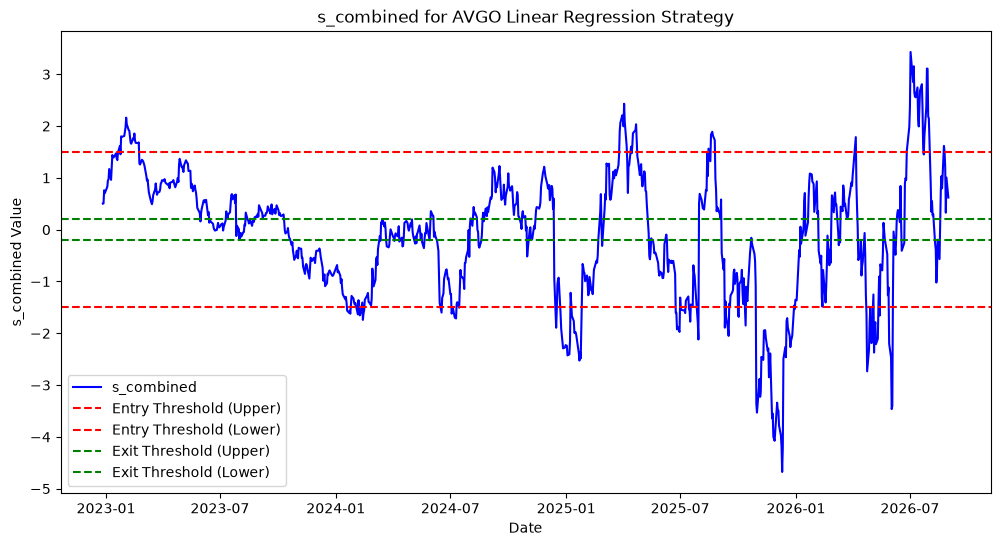

In [71]:
# Plot s_combined
plt.figure(figsize=(12, 6))
plt.plot(s_combined, label='s_combined', color='blue')
plt.axhline(y=theta_entry, color='red', linestyle='--', label='Entry Threshold (Upper)')
plt.axhline(y=-theta_entry, color='red', linestyle='--', label='Entry Threshold (Lower)')
plt.axhline(y=theta_exit, color='green', linestyle='--', label='Exit Threshold (Upper)')
plt.axhline(y=-theta_exit, color='green', linestyle='--', label='Exit Threshold (Lower)')
plt.title(f's_combined for {STOCK} Linear Regression Strategy')
plt.xlabel('Date')
plt.ylabel('s_combined Value')
plt.legend()
plt.show()

In [72]:
# Determine entry and exit signals
positions = pd.DataFrame(index=stock.index)
positions['position'] = 0

current_pos = 0
prev_pos = 0
for i in positions.index:
    s = s_combined.loc[i, 'S_combined']
    if pd.isna(s):
        continue  # Skip if s_combined is NaN

    prev_pos = current_pos

    def set_position(i, pos):
        positions.loc[i, 'position'] = pos

    if prev_pos == 0:
        if s >= theta_entry:
            current_pos = 1 # Long
            set_position(i, current_pos)
            continue
        if s <= -theta_entry:
            current_pos = -1 # Short
            set_position(i, current_pos)
            continue
        current_pos = 0 # No position
        set_position(i, current_pos)
        continue

    if prev_pos == 1:
        if s <= theta_exit:
            current_pos = 0 # Exit long
            set_position(i, current_pos)
            continue
        current_pos = 1 # Maintain long
        set_position(i, current_pos)
        continue

    if prev_pos == -1:
        if s >= -theta_exit:
            current_pos = 0 # Exit short
            set_position(i, current_pos)
            continue
        current_pos = -1 # Maintain short
        set_position(i, current_pos)
        continue

positions.head()

,position
Date,
2022-10-03 00:00:00-04:00,0
2022-10-04 00:00:00-04:00,0
2022-10-05 00:00:00-04:00,0
2022-10-06 00:00:00-04:00,0
2022-10-07 00:00:00-04:00,0


## Backtesting

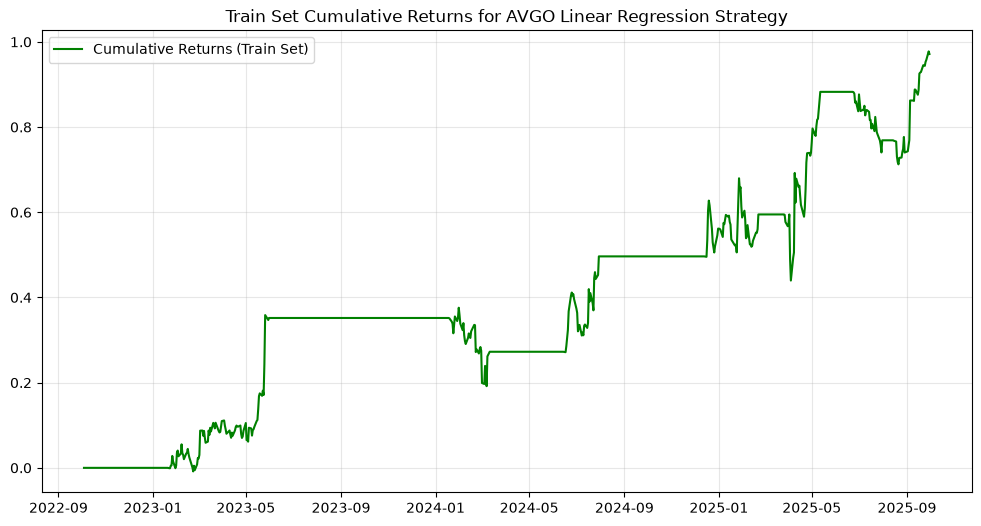

In [73]:
# Compute portfolio returns
portfolio_return = pd.DataFrame(index=stock.index)
portfolio_return['gross_return'] = positions['position'].shift(1) * stock['Close'].pct_change()
portfolio_return['trades'] = positions['position'].diff().fillna(0).abs()
portfolio_return['transaction_costs'] = portfolio_return['trades'] * TRANSACTION_COST_RATE
portfolio_return['net_return'] = portfolio_return['gross_return'] - portfolio_return['transaction_costs']

# Calculate profit and loss (PnL)
pnl_train = portfolio_return[TRAIN_RANGE]['net_return'].cumsum()

# Plot the cumulative PnL
plt.figure(figsize=(12, 6))
plt.plot(pnl_train, label='Cumulative Returns (Train Set)', color='green')
plt.title(f'Train Set Cumulative Returns for {STOCK} Linear Regression Strategy')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

In [74]:
r_train = portfolio_return['net_return'][TRAIN_RANGE]
sharpe_train = r_train.mean() / r_train.std() * np.sqrt(252)  # Annualized Sharpe ratio
print(f"Train Set Sharpe Ratio: {sharpe_train:.4f}")

mdd_train = (pnl_train.cummax() - pnl_train).max()
drawdown_trough_train = (pnl_train.cummax() - pnl_train).idxmax()
drawdown_peak_train = pnl_train[:drawdown_trough_train].idxmax()
mdd_duration_train = drawdown_trough_train - drawdown_peak_train
print(f"Train Set Maximum Drawdown: {mdd_train:.4f}")
print(f"Train Set Maximum Drawdown Duration: {mdd_duration_train.days} days")

Train Set Sharpe Ratio: 1.1394
Train Set Maximum Drawdown: 0.2401
Train Set Maximum Drawdown Duration: 66 days


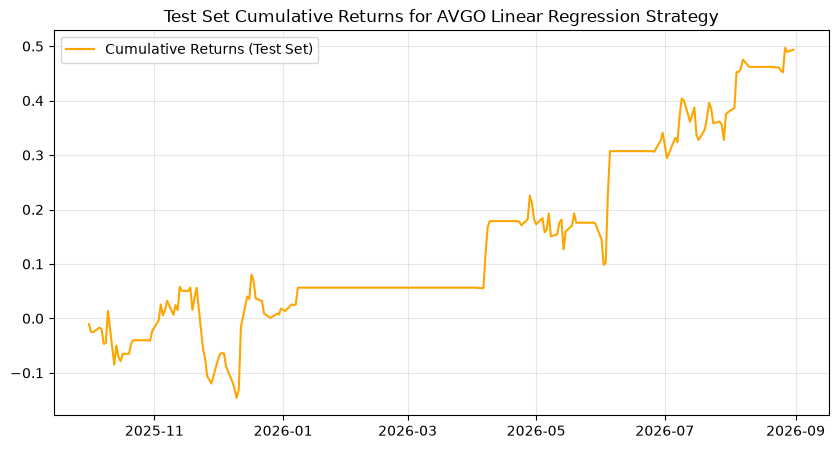

In [75]:
pnl_test = portfolio_return['net_return'][TEST_RANGE].cumsum()
plt.figure(figsize=(10, 5))
plt.plot(pnl_test, label='Cumulative Returns (Test Set)', color='orange')
plt.title(f'Test Set Cumulative Returns for {STOCK} Linear Regression Strategy')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

In [76]:
r_test = portfolio_return['net_return'][TEST_RANGE]
sharpe_test = r_test.mean() / (r_test.std() + 1e-12) * np.sqrt(252)
print(f"Test Set Sharpe Ratio: {sharpe_test:.4f}")

mdd_test = (pnl_test.cummax() - pnl_test).max()
drawdown_trough_test = (pnl_test.cummax() - pnl_test).idxmax()
drawdown_peak_test = pnl_test[:drawdown_trough_test].idxmax()
mdd_duration_test = drawdown_trough_test - drawdown_peak_test
print(f"Test Set Maximum Drawdown: {mdd_test:.4f}")
print(f"Test Set Maximum Drawdown Duration: {mdd_duration_test.days} days")

Test Set Sharpe Ratio: 1.4291
Test Set Maximum Drawdown: 0.2041
Test Set Maximum Drawdown Duration: 27 days
